# Lead-Time-Aware Predictive Incident Detection

In [ ]:
# Cell 1 — Imports & Constants
import subprocess, sys
for pkg in ['matplotlib', 'seaborn', 'tqdm', 'tabulate']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from tabulate import tabulate
import time
import sklearn

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

# Constants
DATA_PATH = 'KPI-Anomaly-Detection-master/Preliminary_dataset/train.csv'
HORIZONS = [5, 10, 15]          # prediction horizons in minutes
TRAIN_FRAC = 0.70               # time-based train/test split
RANDOM_STATE = 42

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 11.5 MB/s  0:00:002.7 MB/s eta 0:00:01:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... error
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [669 lines of output]
      Partial import of sklearn during the build process.
      clang: error: unsupported option '-fopenmp'
      clang: error: unsupported option '-fopenmp'
      /private/var/folders/7x/03lynn_91j95qwgllvmwv8m40000gn/T/pip-install-f9aqwznk/scikit-learn_5e9262e255054808beb760524de20c58/sklearn/_build_utils/openmp_helpers.py:121: UserWarning:
      
                      ***********
                      * WARNING *
                      ***********
      
      It seems that scikit-learn cannot be built with OpenMP.
      
      - Make sure you have followed the installation instructions:
      
         


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
print(sklearn.__version__)

1.8.0


In [7]:
# Cell 2 — Load data & compute per-KPI metadata
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} rows, columns: {list(df.columns)}')
print(f'Unique KPIs: {df["KPI ID"].nunique()}')
print()

# Compute per-KPI metadata
kpi_meta = []
for kpi_id, grp in df.groupby('KPI ID'):
    grp_sorted = grp.sort_values('timestamp')
    diffs = grp_sorted['timestamp'].diff().dropna()
    interval_sec = int(diffs.median())
    n_rows = len(grp_sorted)
    anomaly_rate = grp_sorted['label'].mean()
    n_anomalies = grp_sorted['label'].sum()
    kpi_meta.append({
        'KPI ID': kpi_id,
        'interval_sec': interval_sec,
        'n_rows': n_rows,
        'anomaly_rate': round(anomaly_rate, 4),
        'n_anomalies': int(n_anomalies)
    })

kpi_meta_df = pd.DataFrame(kpi_meta)
print(f'Interval distribution: {kpi_meta_df["interval_sec"].value_counts().to_dict()}')
print(f'Total anomalous rows: {kpi_meta_df["n_anomalies"].sum():,} '
      f'({kpi_meta_df["n_anomalies"].sum() / len(df) * 100:.2f}%)')
print()
print(kpi_meta_df.to_string(index=False))

Loaded 2,476,315 rows, columns: ['timestamp', 'value', 'label', 'KPI ID']
Unique KPIs: 26

Interval distribution: {60: 19, 300: 7}
Total anomalous rows: 53,500 (2.16%)

          KPI ID  interval_sec  n_rows  anomaly_rate  n_anomalies
02e99bd4f6cfb33f            60  128562        0.0821        10550
046ec29ddf80d62e           300    8784        0.0091           80
07927a9a18fa19ae           300   10960        0.0119          130
09513ae3e75778a3            60  128971        0.0018          238
18fbb1d5a5dc099d            60  129128        0.0609         7863
1c35dbf57f55f5e4            60  128853        0.0744         9581
40e25005ff8992bd            60  100254        0.0065          654
54e8a140f6237526           300    8248        0.0005            4
71595dd7171f4540            60  147668        0.0075         1113
769894baefea4e9e           300    8784        0.0010            9
76f4550c43334374           300    8784        0.0099           87
7c189dd36f048a6c            60  147689 

In [8]:
# Cell 3 — Forward-looking label construction

def construct_forward_labels(labels, n_forward_steps):
    """
    For each timestep t, label_H(t) = 1 if any original label=1 in [t, t+H].
    Uses reverse-rolling-max trick: reverse the series, apply rolling max,
    then reverse back.
    
    Parameters
    ----------
    labels : pd.Series — original binary labels (sorted by time)
    n_forward_steps : int — number of future steps to look ahead
    
    Returns
    -------
    pd.Series — forward-looking binary labels (same index)
    """
    window = n_forward_steps + 1  # inclusive of current step
    reversed_labels = labels.iloc[::-1].reset_index(drop=True)
    forward = reversed_labels.rolling(window=window, min_periods=1).max()
    forward = forward.iloc[::-1].reset_index(drop=True)
    forward.index = labels.index
    return forward.astype(int)

print('construct_forward_labels() defined.')

# Quick test
test_labels = pd.Series([0, 0, 0, 1, 1, 0, 0, 0, 0, 1])
test_fwd = construct_forward_labels(test_labels, n_forward_steps=2)
print(f'Test original:  {test_labels.tolist()}')
print(f'Test forward-2: {test_fwd.tolist()}')
assert test_fwd.tolist() == [0, 1, 1, 1, 1, 0, 0, 1, 1, 1], 'Forward label test failed!'
print('Test passed.')

construct_forward_labels() defined.
Test original:  [0, 0, 0, 1, 1, 0, 0, 0, 0, 1]
Test forward-2: [0, 1, 1, 1, 1, 0, 0, 1, 1, 1]
Test passed.


In [9]:
# Cell 4 — Apply forward labels to all horizons

# Sort data by KPI and timestamp
df = df.sort_values(['KPI ID', 'timestamp']).reset_index(drop=True)

# Build a lookup for interval_sec per KPI
kpi_interval = dict(zip(kpi_meta_df['KPI ID'], kpi_meta_df['interval_sec']))

# Construct forward labels for each horizon
for H in HORIZONS:
    col = f'label_H{H}'
    parts = []
    for kpi_id, grp in df.groupby('KPI ID'):
        interval = kpi_interval[kpi_id]
        n_forward = H * 60 // interval
        fwd = construct_forward_labels(grp['label'], n_forward)
        parts.append(fwd)
    df[col] = pd.concat(parts)

# Print expansion statistics
print('Forward-label expansion statistics:')
print(f'{"Horizon":>10} {"Original %":>12} {"Forward %":>12} {"Expansion":>12}')
orig_rate = df['label'].mean()
for H in HORIZONS:
    col = f'label_H{H}'
    fwd_rate = df[col].mean()
    print(f'{H:>8}m {orig_rate*100:>11.2f}% {fwd_rate*100:>11.2f}% {fwd_rate/orig_rate:>11.2f}x')

print(f'\nOriginal positive rate: {orig_rate*100:.2f}%')

Forward-label expansion statistics:
   Horizon   Original %    Forward %    Expansion
       5m        2.16%        2.34%        1.09x
      10m        2.16%        2.53%        1.17x
      15m        2.16%        2.70%        1.25x

Original positive rate: 2.16%


In [10]:
# Cell 5 — KPI feature engineering

def compute_kpi_features(values, window_steps):
    """
    Compute rolling statistical features from KPI values.
    
    Parameters
    ----------
    values : pd.Series — KPI values (sorted by time)
    window_steps : int — rolling window size in timesteps
    
    Returns
    -------
    pd.DataFrame — feature columns: roll_mean, roll_max, roll_std, roll_slope, first_diff
    """
    w = max(window_steps, 2)  # minimum window of 2 for meaningful stats
    
    roll = values.rolling(window=w, min_periods=w)
    
    features = pd.DataFrame(index=values.index)
    features['roll_mean'] = roll.mean()
    features['roll_max'] = roll.max()
    features['roll_std'] = roll.std(ddof=0)
    
    # Roll slope: linear regression coefficient over window
    x_range = np.arange(w, dtype=float)
    x_mean = x_range.mean()
    x_var = ((x_range - x_mean) ** 2).sum()
    
    def slope_func(y):
        if len(y) < w:
            return np.nan
        return np.sum((x_range - x_mean) * (y - y.mean())) / x_var
    
    features['roll_slope'] = roll.apply(slope_func, raw=True)
    
    # First difference
    features['first_diff'] = values.diff()
    
    return features

In [11]:
# Cell 6 — Log-proxy feature engineering

def compute_log_proxy_features(values, window_steps):
    """
    Compute synthetic numeric signals that proxy for log-derived features.
    No text or NLP — purely derived from KPI dynamics.
    
    Parameters
    ----------
    values : pd.Series — KPI values (sorted by time)
    window_steps : int — rolling window size in timesteps
    
    Returns
    -------
    pd.DataFrame — feature columns: error_rate, warn_rate, severity_change_flag
    """
    w = max(window_steps, 2)
    
    features = pd.DataFrame(index=values.index)
    
    # Z-score spikes: |z| > 3
    roll_mean = values.rolling(window=w, min_periods=w).mean()
    roll_std = values.rolling(window=w, min_periods=w).std(ddof=0)
    z_score = ((values - roll_mean) / roll_std.replace(0, np.nan)).fillna(0)
    z_spike = (z_score.abs() > 3).astype(float)
    features['error_rate'] = z_spike.rolling(window=w, min_periods=w).mean()
    
    # Large jumps: |diff| > 2 * rolling_std
    diff = values.diff().abs()
    large_jump = (diff > 2 * roll_std).astype(float)
    features['warn_rate'] = large_jump.rolling(window=w, min_periods=w).mean()
    
    # Severity change flag: >50% change in error_rate or warn_rate vs prior window
    err_prev = features['error_rate'].shift(w)
    warn_prev = features['warn_rate'].shift(w)
    
    err_change = (features['error_rate'] - err_prev).abs() / err_prev.replace(0, np.nan)
    warn_change = (features['warn_rate'] - warn_prev).abs() / warn_prev.replace(0, np.nan)
    
    features['severity_change_flag'] = (
        (err_change.fillna(0) > 0.5) | (warn_change.fillna(0) > 0.5)
    ).astype(int)
    
    return features

In [12]:
# Cell 7 — Build feature matrices for all horizons

KPI_ONLY_COLS = ['roll_mean', 'roll_max', 'roll_std', 'roll_slope', 'first_diff']
LOG_PROXY_COLS = ['error_rate', 'warn_rate', 'severity_change_flag']
KPI_PLUS_LOGS_COLS = KPI_ONLY_COLS + LOG_PROXY_COLS

feature_data = {}  # key: (H, fset) -> {X_train, y_train, X_test, y_test, meta_test, meta_train}

for H in HORIZONS:
    print(f'\n=== Horizon H={H} min ===')
    label_col = f'label_H{H}'
    
    all_kpi_features = []  # list of per-KPI DataFrames
    
    for kpi_id, grp in tqdm(df.groupby('KPI ID'), desc=f'H={H} features'):
        grp = grp.copy()
        interval = kpi_interval[kpi_id]
        window_steps = H * 60 // interval
        
        # Compute features
        kpi_feats = compute_kpi_features(grp['value'], window_steps)
        log_feats = compute_log_proxy_features(grp['value'], window_steps)
        
        feat_df = pd.concat([kpi_feats, log_feats], axis=1)
        feat_df['label_fwd'] = grp[label_col].values
        feat_df['label_orig'] = grp['label'].values
        feat_df['timestamp'] = grp['timestamp'].values
        feat_df['KPI_ID'] = kpi_id
        feat_df['interval_sec'] = interval
        
        # Drop NaN rows (from rolling windows)
        feat_df = feat_df.dropna(subset=KPI_PLUS_LOGS_COLS)
        
        # Time-based 70/30 split
        n = len(feat_df)
        split_idx = int(n * TRAIN_FRAC)
        feat_df['split'] = 'test'
        feat_df.iloc[:split_idx, feat_df.columns.get_loc('split')] = 'train'
        
        # Per-KPI z-score normalization (train stats only)
        train_mask = feat_df['split'] == 'train'
        for col in KPI_PLUS_LOGS_COLS:
            mu = feat_df.loc[train_mask, col].mean()
            sigma = feat_df.loc[train_mask, col].std()
            if sigma == 0 or np.isnan(sigma):
                sigma = 1.0
            feat_df[col] = (feat_df[col] - mu) / sigma
        
        all_kpi_features.append(feat_df)
    
    # Concatenate all KPIs
    combined = pd.concat(all_kpi_features, ignore_index=True)
    
    train = combined[combined['split'] == 'train']
    test = combined[combined['split'] == 'test']
    
    for fset, cols in [('KPI_ONLY', KPI_ONLY_COLS), ('KPI_PLUS_LOGS', KPI_PLUS_LOGS_COLS)]:
        feature_data[(H, fset)] = {
            'X_train': train[cols].values.astype(np.float32),
            'y_train': train['label_fwd'].values.astype(int),
            'X_test': test[cols].values.astype(np.float32),
            'y_test': test['label_fwd'].values.astype(int),
            'meta_test': test[['timestamp', 'KPI_ID', 'label_orig', 'interval_sec']].reset_index(drop=True),
            'meta_train': train[['timestamp', 'KPI_ID', 'label_orig', 'interval_sec']].reset_index(drop=True),
        }
    
    n_train = len(train)
    n_test = len(test)
    print(f'  Train: {n_train:,} rows | Test: {n_test:,} rows')
    print(f'  Train positive rate: {train["label_fwd"].mean()*100:.2f}%')
    print(f'  Test positive rate:  {test["label_fwd"].mean()*100:.2f}%')
    
    # Free memory
    del combined, train, test, all_kpi_features

print(f'\nFeature data built for {len(feature_data)} (horizon, feature_set) combinations.')

# Document degenerate cases
print('\nDegenerate feature cases (window_steps <= 1):')
for kpi_id in kpi_meta_df['KPI ID']:
    interval = kpi_interval[kpi_id]
    for H in HORIZONS:
        ws = H * 60 // interval
        if ws <= 1:
            print(f'  KPI {kpi_id[:8]}... interval={interval}s, H={H}min -> window_steps={ws}')


=== Horizon H=5 min ===


H=5 features: 100%|██████████| 26/26 [00:11<00:00,  2.34it/s]


  Train: 1,733,352 rows | Test: 742,880 rows
  Train positive rate: 2.49%
  Test positive rate:  2.02%

=== Horizon H=10 min ===


H=10 features: 100%|██████████| 26/26 [00:11<00:00,  2.32it/s]


  Train: 1,733,287 rows | Test: 742,850 rows
  Train positive rate: 2.67%
  Test positive rate:  2.20%

=== Horizon H=15 min ===


H=15 features: 100%|██████████| 26/26 [00:11<00:00,  2.30it/s]


  Train: 1,733,213 rows | Test: 742,822 rows
  Train positive rate: 2.85%
  Test positive rate:  2.37%

Feature data built for 6 (horizon, feature_set) combinations.

Degenerate feature cases (window_steps <= 1):
  KPI 046ec29d... interval=300s, H=5min -> window_steps=1
  KPI 07927a9a... interval=300s, H=5min -> window_steps=1
  KPI 54e8a140... interval=300s, H=5min -> window_steps=1
  KPI 769894ba... interval=300s, H=5min -> window_steps=1
  KPI 76f4550c... interval=300s, H=5min -> window_steps=1
  KPI 8a20c229... interval=300s, H=5min -> window_steps=1
  KPI b3b2e6d1... interval=300s, H=5min -> window_steps=1


In [13]:
# Cell 8 — Model definitions (LOCKED)

MODEL_DEFS = {
    'GBC': GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE
    ),
    'LR': LogisticRegression(
        random_state=RANDOM_STATE, max_iter=1000
    ),
    'RF': RandomForestClassifier(
        n_estimators=100, max_depth=3, random_state=RANDOM_STATE
    ),
}

print('Model definitions (LOCKED — no hyperparameter tuning):')
for name, model in MODEL_DEFS.items():
    print(f'  {name}: {model}')

Model definitions (LOCKED — no hyperparameter tuning):
  GBC: GradientBoostingClassifier(random_state=42)
  LR: LogisticRegression(max_iter=1000, random_state=42)
  RF: RandomForestClassifier(max_depth=3, random_state=42)


In [14]:
# Cell 9 — Train all models

from sklearn.base import clone

trained_models = {}  # key: (H, fset, model_name) -> fitted model
predictions = {}     # key: (H, fset, model_name) -> {'train_scores', 'test_scores'}

total_fits = len(HORIZONS) * 2 * len(MODEL_DEFS)  # 3 * 2 * 3 = 18
fit_count = 0

for H in HORIZONS:
    for fset in ['KPI_ONLY', 'KPI_PLUS_LOGS']:
        fd = feature_data[(H, fset)]
        X_train, y_train = fd['X_train'], fd['y_train']
        X_test, y_test = fd['X_test'], fd['y_test']
        
        for model_name, model_template in MODEL_DEFS.items():
            fit_count += 1
            key = (H, fset, model_name)
            
            print(f'[{fit_count}/{total_fits}] Training {model_name} | H={H} | {fset} '
                  f'| train={len(X_train):,} rows...', end=' ')
            
            model = clone(model_template)
            t0 = time.time()
            model.fit(X_train, y_train)
            elapsed = time.time() - t0
            
            train_scores = model.predict_proba(X_train)[:, 1]
            test_scores = model.predict_proba(X_test)[:, 1]
            
            trained_models[key] = model
            predictions[key] = {
                'train_scores': train_scores,
                'test_scores': test_scores,
            }
            
            print(f'{elapsed:.1f}s')

print(f'\nAll {total_fits} models trained.')

[1/18] Training GBC | H=5 | KPI_ONLY | train=1,733,352 rows... 

KeyboardInterrupt: 

In [ ]:
# Cell 10 — Alert threshold calibration

def calibrate_threshold_per_kpi(train_scores, meta_train, y_train):
    """
    Calibrate alert thresholds per KPI targeting 1 false alert per 24 hours.
    
    For each KPI:
    - target_FPR = 1 / (24 * 3600 / interval_sec)
    - threshold = quantile(normal_training_scores, 1 - target_FPR)
    
    Parameters
    ----------
    train_scores : np.ndarray — prediction scores on training set
    meta_train : pd.DataFrame — with 'KPI_ID', 'interval_sec' columns
    y_train : np.ndarray — forward labels on training set
    
    Returns
    -------
    dict — KPI_ID -> threshold
    """
    thresholds = {}
    for kpi_id in meta_train['KPI_ID'].unique():
        mask = (meta_train['KPI_ID'].values == kpi_id)
        normal_mask = mask & (y_train == 0)
        
        normal_scores = train_scores[normal_mask]
        
        interval = meta_train.loc[mask, 'interval_sec'].iloc[0]
        steps_per_day = 24 * 3600 / interval
        target_fpr = 1.0 / steps_per_day
        
        if len(normal_scores) > 0:
            threshold = np.quantile(normal_scores, 1.0 - target_fpr)
        else:
            threshold = 0.5  # fallback
        
        thresholds[kpi_id] = threshold
    
    return thresholds

In [ ]:
# Cell 11 — Apply calibration to all 18 models

calibrated_thresholds = {}  # key: (H, fset, model_name) -> {KPI_ID: threshold}
alert_vectors = {}          # key: (H, fset, model_name) -> np.ndarray (test set alerts)

for H in HORIZONS:
    for fset in ['KPI_ONLY', 'KPI_PLUS_LOGS']:
        fd = feature_data[(H, fset)]
        meta_train = fd['meta_train']
        meta_test = fd['meta_test']
        y_train = fd['y_train']
        
        for model_name in MODEL_DEFS:
            key = (H, fset, model_name)
            train_scores = predictions[key]['train_scores']
            test_scores = predictions[key]['test_scores']
            
            # Calibrate on training data
            thresholds = calibrate_threshold_per_kpi(train_scores, meta_train, y_train)
            calibrated_thresholds[key] = thresholds
            
            # Apply to test data
            alerts = np.zeros(len(test_scores), dtype=int)
            for kpi_id, thr in thresholds.items():
                kpi_mask = (meta_test['KPI_ID'].values == kpi_id)
                alerts[kpi_mask] = (test_scores[kpi_mask] > thr).astype(int)
            
            alert_vectors[key] = alerts

print(f'Calibrated thresholds and alert vectors computed for {len(alert_vectors)} models.')

# Also store p=0.5 reference alerts
alert_vectors_p50 = {}
for key in predictions:
    alert_vectors_p50[key] = (predictions[key]['test_scores'] > 0.5).astype(int)

print(f'Fixed p=0.5 alert vectors computed for {len(alert_vectors_p50)} models.')

Calibrated thresholds and alert vectors computed for 18 models.
Fixed p=0.5 alert vectors computed for 18 models.


In [ ]:
# Cell 12 — Reactive Baseline 1 — Static threshold

baseline_static_alerts = {}  # key: H -> np.ndarray (test set alerts, same length as feature_data test)

for H in HORIZONS:
    fd = feature_data[(H, 'KPI_ONLY')]  # use KPI_ONLY meta (same rows for both feature sets)
    meta_train = fd['meta_train']
    meta_test = fd['meta_test']
    y_train = fd['y_train']
    
    # Need original values, reconstruct from df
    # Build lookup: (timestamp, KPI_ID) -> value
    value_lookup = dict(zip(zip(df['timestamp'], df['KPI ID']), df['value']))
    
    train_values = np.array([value_lookup.get((t, k), np.nan) 
                             for t, k in zip(meta_train['timestamp'], meta_train['KPI_ID'])])
    test_values = np.array([value_lookup.get((t, k), np.nan) 
                            for t, k in zip(meta_test['timestamp'], meta_test['KPI_ID'])])
    
    alerts = np.zeros(len(test_values), dtype=int)
    
    for kpi_id in meta_train['KPI_ID'].unique():
        train_mask = (meta_train['KPI_ID'].values == kpi_id)
        test_mask = (meta_test['KPI_ID'].values == kpi_id)
        normal_train_mask = train_mask & (y_train == 0)
        
        normal_vals = train_values[normal_train_mask]
        
        interval = meta_train.loc[train_mask, 'interval_sec'].iloc[0]
        steps_per_day = 24 * 3600 / interval
        target_fpr = 1.0 / steps_per_day
        
        # Split FPR budget equally between upper and lower tails
        half_fpr = target_fpr / 2.0
        
        if len(normal_vals) > 0:
            upper_thr = np.quantile(normal_vals, 1.0 - half_fpr)
            lower_thr = np.quantile(normal_vals, half_fpr)
        else:
            upper_thr = np.inf
            lower_thr = -np.inf
        
        test_vals_kpi = test_values[test_mask]
        alerts[test_mask] = ((test_vals_kpi > upper_thr) | (test_vals_kpi < lower_thr)).astype(int)
    
    baseline_static_alerts[H] = alerts
    print(f'H={H}: Static baseline alert rate = {alerts.mean()*100:.4f}%')

print('Reactive Baseline 1 (static threshold) computed.')

H=5: Static baseline alert rate = 1.7886%
H=10: Static baseline alert rate = 1.7884%
H=15: Static baseline alert rate = 1.7882%
Reactive Baseline 1 (static threshold) computed.


In [ ]:
# Cell 13 — Reactive Baseline 2 — Moving-average breach

baseline_ma_alerts = {}  # key: H -> np.ndarray

for H in HORIZONS:
    fd = feature_data[(H, 'KPI_ONLY')]
    meta_train = fd['meta_train']
    meta_test = fd['meta_test']
    y_train = fd['y_train']
    
    alerts = np.zeros(len(meta_test), dtype=int)
    
    for kpi_id, grp in df.groupby('KPI ID'):
        grp = grp.copy().sort_values('timestamp')
        interval = kpi_interval[kpi_id]
        
        # 60-min lookback window
        lookback_steps = max(60 * 60 // interval, 2)
        
        ma = grp['value'].rolling(window=lookback_steps, min_periods=lookback_steps).mean()
        roll_std = grp['value'].rolling(window=lookback_steps, min_periods=lookback_steps).std(ddof=0)
        
        deviation_score = ((grp['value'] - ma) / roll_std.replace(0, np.nan)).abs().fillna(0)
        
        # Map scores back to train/test via timestamp
        score_lookup = dict(zip(grp['timestamp'], deviation_score))
        
        train_mask_meta = (meta_train['KPI_ID'].values == kpi_id)
        test_mask_meta = (meta_test['KPI_ID'].values == kpi_id)
        
        # Get training scores for calibration
        train_timestamps = meta_train.loc[train_mask_meta, 'timestamp'].values
        train_dev_scores = np.array([score_lookup.get(t, 0.0) for t in train_timestamps])
        train_labels = y_train[train_mask_meta]
        
        normal_scores = train_dev_scores[train_labels == 0]
        
        steps_per_day = 24 * 3600 / interval
        target_fpr = 1.0 / steps_per_day
        
        if len(normal_scores) > 0:
            thr = np.quantile(normal_scores, 1.0 - target_fpr)
        else:
            thr = np.inf
        
        # Apply to test
        test_timestamps = meta_test.loc[test_mask_meta, 'timestamp'].values
        test_dev_scores = np.array([score_lookup.get(t, 0.0) for t in test_timestamps])
        alerts[test_mask_meta] = (test_dev_scores > thr).astype(int)
    
    baseline_ma_alerts[H] = alerts
    print(f'H={H}: MA-breach baseline alert rate = {alerts.mean()*100:.4f}%')

print('Reactive Baseline 2 (moving-average breach) computed.')

H=5: MA-breach baseline alert rate = 0.1377%
H=10: MA-breach baseline alert rate = 0.1376%
H=15: MA-breach baseline alert rate = 0.1376%
Reactive Baseline 2 (moving-average breach) computed.


In [ ]:
# Cell 14 — Lead time & metrics computation

def compute_lead_times_and_metrics(alerts, y_test_fwd, meta_test, horizon_min, eval_window_min=60):
    """
    Compute lead times and classification metrics.
    
    Parameters
    ----------
    alerts : np.ndarray — binary alert vector (test set)
    y_test_fwd : np.ndarray — forward-looking labels (test set)
    meta_test : pd.DataFrame — with 'timestamp', 'KPI_ID', 'label_orig'
    horizon_min : int — the model's training horizon (for reporting)
    eval_window_min : int — how far back (minutes) to search for alerts before each incident
    
    Returns
    -------
    dict with keys: mean_lead_time, median_lead_time, precision, recall,
                    n_incidents, n_detected, lead_times (list)
    """

    eval_window_sec = eval_window_min * 60
    lead_times = []
    n_incidents = 0
    n_detected = 0

    required_cols = {'timestamp', 'KPI_ID', 'label_orig'}
    missing = required_cols - set(meta_test.columns)
    if missing:
        raise ValueError(f"meta_test missing required columns: {missing}")

    timestamps_all = meta_test['timestamp'].values
    kpi_ids_all = meta_test['KPI_ID'].values
    labels_orig_all = meta_test['label_orig'].values

    for kpi_id in np.unique(kpi_ids_all):
        kpi_mask = (kpi_ids_all == kpi_id)

        kpi_timestamps = timestamps_all[kpi_mask]
        kpi_alerts = alerts[kpi_mask]
        kpi_labels_orig = labels_orig_all[kpi_mask]

        # Onsets: positions where label goes 0 -> 1
        prev = np.r_[0, kpi_labels_orig[:-1]]
        onsets = np.where((kpi_labels_orig == 1) & (prev == 0))[0]
        if len(onsets) == 0:
            continue

        n_incidents += len(onsets)

        for onset_idx in onsets:
            onset_time = kpi_timestamps[onset_idx]
            window_start_time = onset_time - eval_window_sec
            
            candidate_mask = (
                (kpi_alerts[:onset_idx] == 1) &
                (kpi_timestamps[:onset_idx] >= window_start_time)
            )
            candidate_indices = np.where(candidate_mask)[0]
            
            if len(candidate_indices) > 0:
                earliest_alert_idx = candidate_indices[0]
                lt_min = (onset_time - kpi_timestamps[earliest_alert_idx]) / 60.0
                lead_times.append(float(lt_min))
                n_detected += 1

    # Precision/recall against forward labels (unchanged)
    prec = precision_score(y_test_fwd, alerts, zero_division=0)
    rec = recall_score(y_test_fwd, alerts, zero_division=0)

    return {
        'mean_lead_time': float(np.mean(lead_times)) if lead_times else 0.0,
        'median_lead_time': float(np.median(lead_times)) if lead_times else 0.0,
        'precision': float(prec),
        'recall': float(rec),
        'n_incidents': int(n_incidents),
        'n_detected': int(n_detected),
        'lead_times': lead_times,
    }

In [ ]:
# Cell 15 — Evaluate all methods

EVAL_WINDOWS = {
    'strict': None,    # will use H as window
    'operational': 60  # 60-min fixed window
}

results = []
lead_time_details = {}

for window_name, fixed_window in EVAL_WINDOWS.items():
    
    # Calibrated threshold models
    for H in HORIZONS:
        eval_w = H if window_name == 'strict' else fixed_window
        
        for fset in ['KPI_ONLY', 'KPI_PLUS_LOGS']:
            fd = feature_data[(H, fset)]
            y_test = fd['y_test']
            meta_test = fd['meta_test']
            
            for model_name in MODEL_DEFS:
                key = (H, fset, model_name)
                alerts = alert_vectors[key]
                
                metrics = compute_lead_times_and_metrics(
                    alerts, y_test, meta_test,
                    horizon_min=H, eval_window_min=eval_w
                )
                method_label = f'{model_name}_{fset}'
                
                results.append({
                    'Method': method_label,
                    'Threshold': 'calibrated',
                    'Eval Window': window_name,
                    'Horizon': H,
                    'Mean Lead Time': metrics['mean_lead_time'],
                    'Median Lead Time': metrics['median_lead_time'],
                    'Precision': metrics['precision'],
                    'Recall': metrics['recall'],
                    'Incidents': metrics['n_incidents'],
                    'Detected': metrics['n_detected'],
                    'Detection Rate': metrics['n_detected'] / metrics['n_incidents'] if metrics['n_incidents'] > 0 else 0,
                })
                lead_time_details[(method_label, H, window_name)] = metrics['lead_times']
        
        # Baselines
        fd = feature_data[(H, 'KPI_ONLY')]
        y_test = fd['y_test']
        meta_test = fd['meta_test']
        
        for bl_name, bl_alerts in [('Baseline_Static', baseline_static_alerts[H]), 
                                     ('Baseline_MA', baseline_ma_alerts[H])]:
            metrics = compute_lead_times_and_metrics(
                bl_alerts, y_test, meta_test,
                horizon_min=H, eval_window_min=eval_w
            )
            results.append({
                'Method': bl_name,
                'Threshold': 'calibrated',
                'Eval Window': window_name,
                'Horizon': H,
                'Mean Lead Time': metrics['mean_lead_time'],
                'Median Lead Time': metrics['median_lead_time'],
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'Incidents': metrics['n_incidents'],
                'Detected': metrics['n_detected'],
                'Detection Rate': metrics['n_detected'] / metrics['n_incidents'] if metrics['n_incidents'] > 0 else 0,
            })
            lead_time_details[(bl_name, H, window_name)] = metrics['lead_times']

# p=0.5 reference (operational window only)
results_p50 = []
for H in HORIZONS:
    for fset in ['KPI_ONLY', 'KPI_PLUS_LOGS']:
        fd = feature_data[(H, fset)]
        y_test = fd['y_test']
        meta_test = fd['meta_test']
        
        for model_name in MODEL_DEFS:
            key = (H, fset, model_name)
            alerts = alert_vectors_p50[key]
            metrics = compute_lead_times_and_metrics(
                alerts, y_test, meta_test,
                horizon_min=H, eval_window_min=60
            )
            method_label = f'{model_name}_{fset}'
            results_p50.append({
                'Method': method_label,
                'Threshold': 'p=0.5',
                'Eval Window': 'operational',
                'Horizon': H,
                'Mean Lead Time': metrics['mean_lead_time'],
                'Median Lead Time': metrics['median_lead_time'],
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'Incidents': metrics['n_incidents'],
                'Detected': metrics['n_detected'],
                'Detection Rate': metrics['n_detected'] / metrics['n_incidents'] if metrics['n_incidents'] > 0 else 0,
            })

results_df = pd.DataFrame(results)
results_p50_df = pd.DataFrame(results_p50)

print(f'Evaluated {len(results)} total method-window combinations.')

Evaluated 48 total method-window combinations.


In [ ]:
# Cell 16 — Summary results table

results_df = pd.DataFrame(results)
results_p50_df = pd.DataFrame(results_p50)

def format_results(df, title):
    display_df = df.copy()
    display_df['Mean Lead Time'] = display_df['Mean Lead Time'].map('{:.2f}'.format)
    display_df['Median Lead Time'] = display_df['Median Lead Time'].map('{:.2f}'.format)
    display_df['Precision'] = display_df['Precision'].map('{:.4f}'.format)
    display_df['Recall'] = display_df['Recall'].map('{:.4f}'.format)
    display_df['Detection Rate'] = display_df['Detection Rate'].map('{:.2%}'.format)
    
    print(f'\n{title}')
    print('=' * 140)
    print(tabulate(
        display_df[['Method', 'Eval Window', 'Horizon', 'Mean Lead Time', 'Median Lead Time',
                     'Precision', 'Recall', 'Incidents', 'Detected', 'Detection Rate']],
        headers='keys',
        tablefmt='pipe',
        showindex=False
    ))

format_results(
    results_df[results_df['Eval Window'] == 'strict'],
    'STRICT WINDOW [T-H, T) — Measures genuine predictive ability'
)
format_results(
    results_df[results_df['Eval Window'] == 'operational'],
    'OPERATIONAL WINDOW [T-60min, T) — Measures practical early warning'
)
format_results(results_p50_df, 'REFERENCE: p=0.5 THRESHOLD (operational window)')


STRICT WINDOW [T-H, T) — Measures genuine predictive ability
| Method            | Eval Window   |   Horizon |   Mean Lead Time |   Median Lead Time |   Precision |   Recall |   Incidents |   Detected | Detection Rate   |
|:------------------|:--------------|----------:|-----------------:|-------------------:|------------:|---------:|------------:|-----------:|:-----------------|
| GBC_KPI_ONLY      | strict        |         5 |             4    |                4   |      0.628  |   0.1923 |         276 |          3 | 1.09%            |
| LR_KPI_ONLY       | strict        |         5 |             5    |                5   |      0.8148 |   0.1567 |         276 |          1 | 0.36%            |
| RF_KPI_ONLY       | strict        |         5 |             0    |                0   |      0.8492 |   0.1578 |         276 |          0 | 0.00%            |
| GBC_KPI_PLUS_LOGS | strict        |         5 |             5    |                5   |      0.8381 |   0.2397 |         276 |     

In [ ]:
# Cell 17 — Timeline plot function

import os 

def plot_kpi_timeline(kpi_id, H, fset='KPI_PLUS_LOGS', model_name='GBC', save=False, out_dir='figures'):
    """
    Two-panel plot for a single KPI:
    - Top: KPI value + incident regions shaded red
    - Bottom: prediction score + threshold lines
    """
    key = (H, fset, model_name)
    fd = feature_data[(H, fset)]
    meta_test = fd['meta_test']
    test_scores = predictions[key]['test_scores']
    thresholds = calibrated_thresholds[key]
    
    kpi_mask = (meta_test['KPI_ID'].values == kpi_id)
    if kpi_mask.sum() == 0:
        print(f'KPI {kpi_id} not found in test set.')
        return
    
    kpi_meta = meta_test[kpi_mask].reset_index(drop=True)
    kpi_scores = test_scores[kpi_mask]
    kpi_labels = kpi_meta['label_orig'].values
    kpi_times = pd.to_datetime(kpi_meta['timestamp'], unit='s')
    
    # Get original values from df
    value_lookup = dict(zip(zip(df['timestamp'], df['KPI ID']), df['value']))
    kpi_values = np.array([value_lookup.get((t, kpi_id), np.nan) 
                           for t in kpi_meta['timestamp']])
    
    threshold = thresholds.get(kpi_id, 0.5)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle(f'KPI: {kpi_id[:12]}...  |  H={H}min  |  {model_name}_{fset}', fontsize=13)
    
    # Top panel: KPI value
    ax1.plot(kpi_times, kpi_values, linewidth=0.5, color='steelblue', label='KPI value')
    
    # Shade incident regions
    in_incident = False
    for i in range(len(kpi_labels)):
        if kpi_labels[i] == 1 and not in_incident:
            start = kpi_times.iloc[i]
            in_incident = True
        elif kpi_labels[i] == 0 and in_incident:
            end = kpi_times.iloc[i-1]
            ax1.axvspan(start, end, alpha=0.3, color='red')
            in_incident = False
    if in_incident:
        ax1.axvspan(start, kpi_times.iloc[-1], alpha=0.3, color='red')
    
    ax1.set_ylabel('KPI Value')
    ax1.legend(loc='upper right')
    
    # Bottom panel: prediction score
    ax2.plot(kpi_times, kpi_scores, linewidth=0.5, color='darkorange', label='Prediction score')
    ax2.axhline(y=threshold, color='red', linestyle='--', linewidth=1, label=f'Calibrated threshold ({threshold:.3f})')
    ax2.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, label='p=0.5 reference')
    ax2.set_ylabel('Score')
    ax2.set_xlabel('Time')
    ax2.legend(loc='upper right')
    ax2.set_ylim(-0.05, 1.05)
    
    plt.tight_layout()

    if save:
        os.makedirs(out_dir, exist_ok=True)
        fname = f'kpi_{kpi_id}_H{H}_{model_name}_{fset}.png'
        path = os.path.join(out_dir, fname)
        plt.savefig(path, dpi=300, bbox_inches='tight')
        print(f'Saved: {path}')

    plt.show()

print('plot_kpi_timeline() defined.')

plot_kpi_timeline() defined.


Selected 3 representative KPIs for timeline plots.
  a5bf5d65261d... test anomaly rate=0.0003
  09513ae3e757... test anomaly rate=0.0034
  1c35dbf57f55... test anomaly rate=0.0702
Saved: figures/timelines/kpi_a5bf5d65261d859a_H5_GBC_KPI_PLUS_LOGS.png


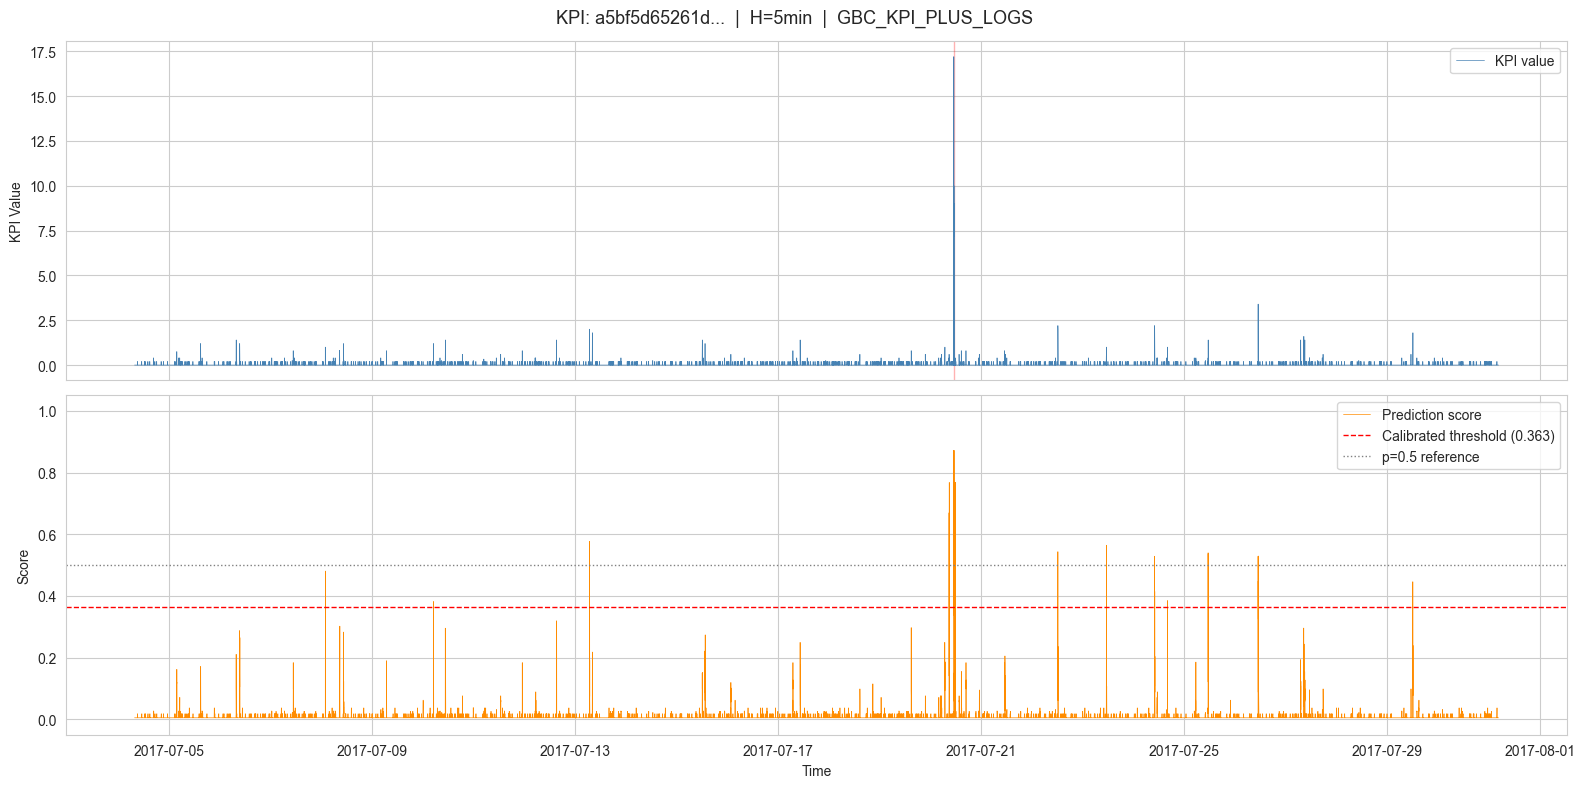

Saved: figures/timelines/kpi_a5bf5d65261d859a_H10_GBC_KPI_PLUS_LOGS.png


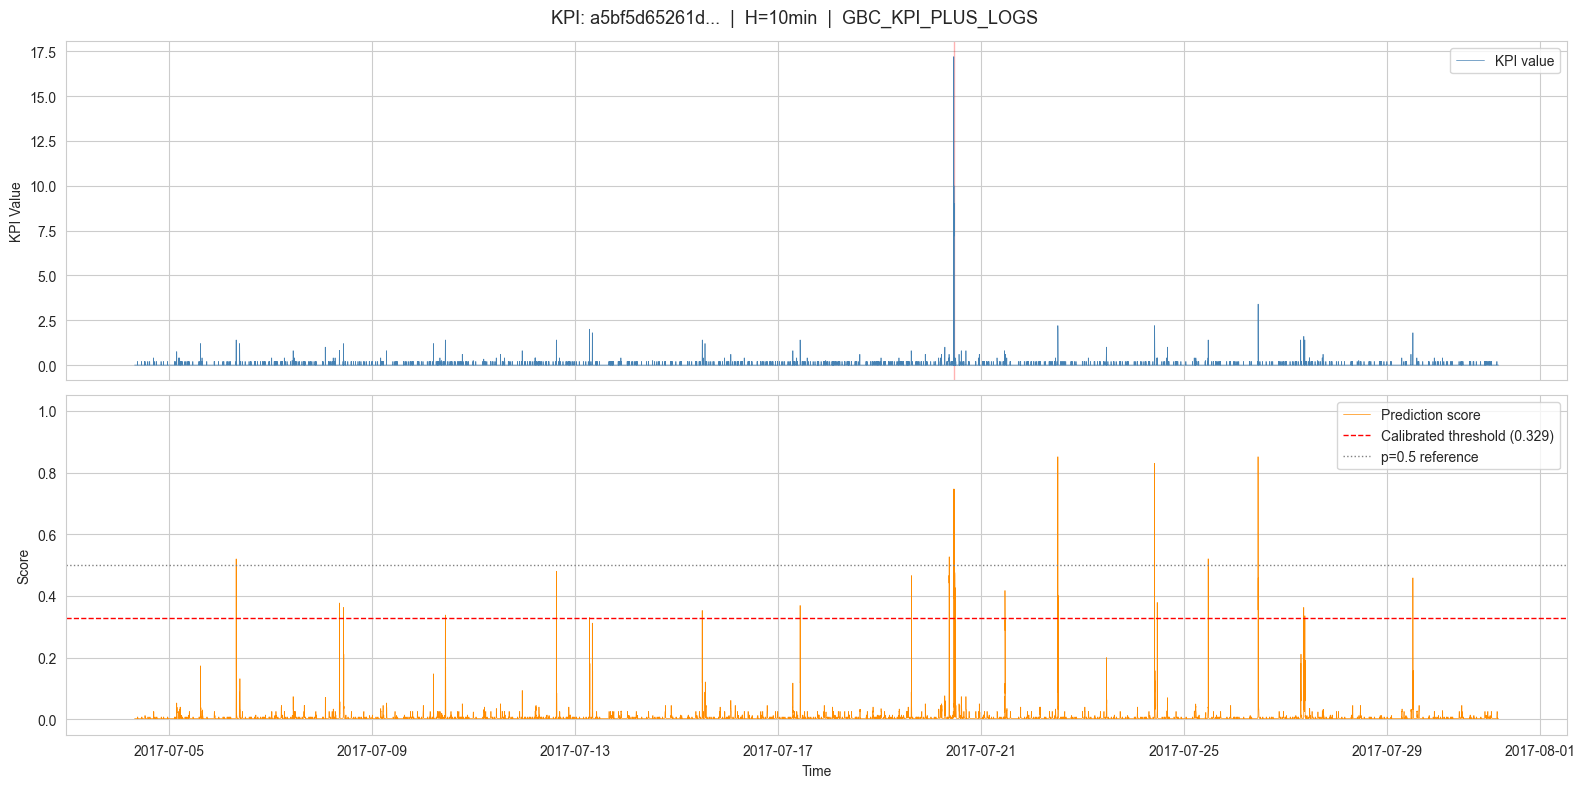

Saved: figures/timelines/kpi_a5bf5d65261d859a_H15_GBC_KPI_PLUS_LOGS.png


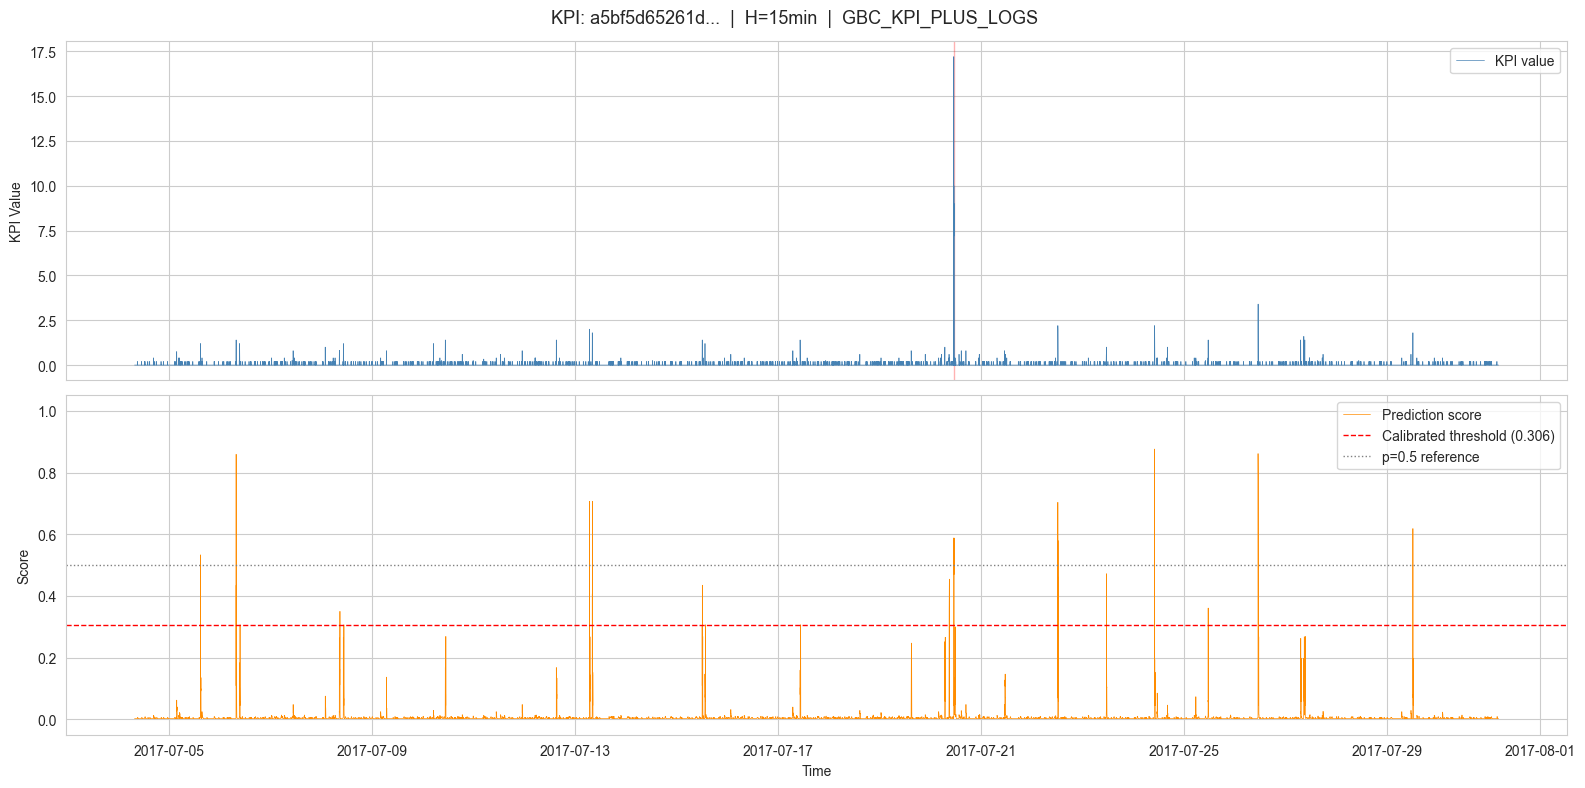

Saved: figures/timelines/kpi_09513ae3e75778a3_H5_GBC_KPI_PLUS_LOGS.png


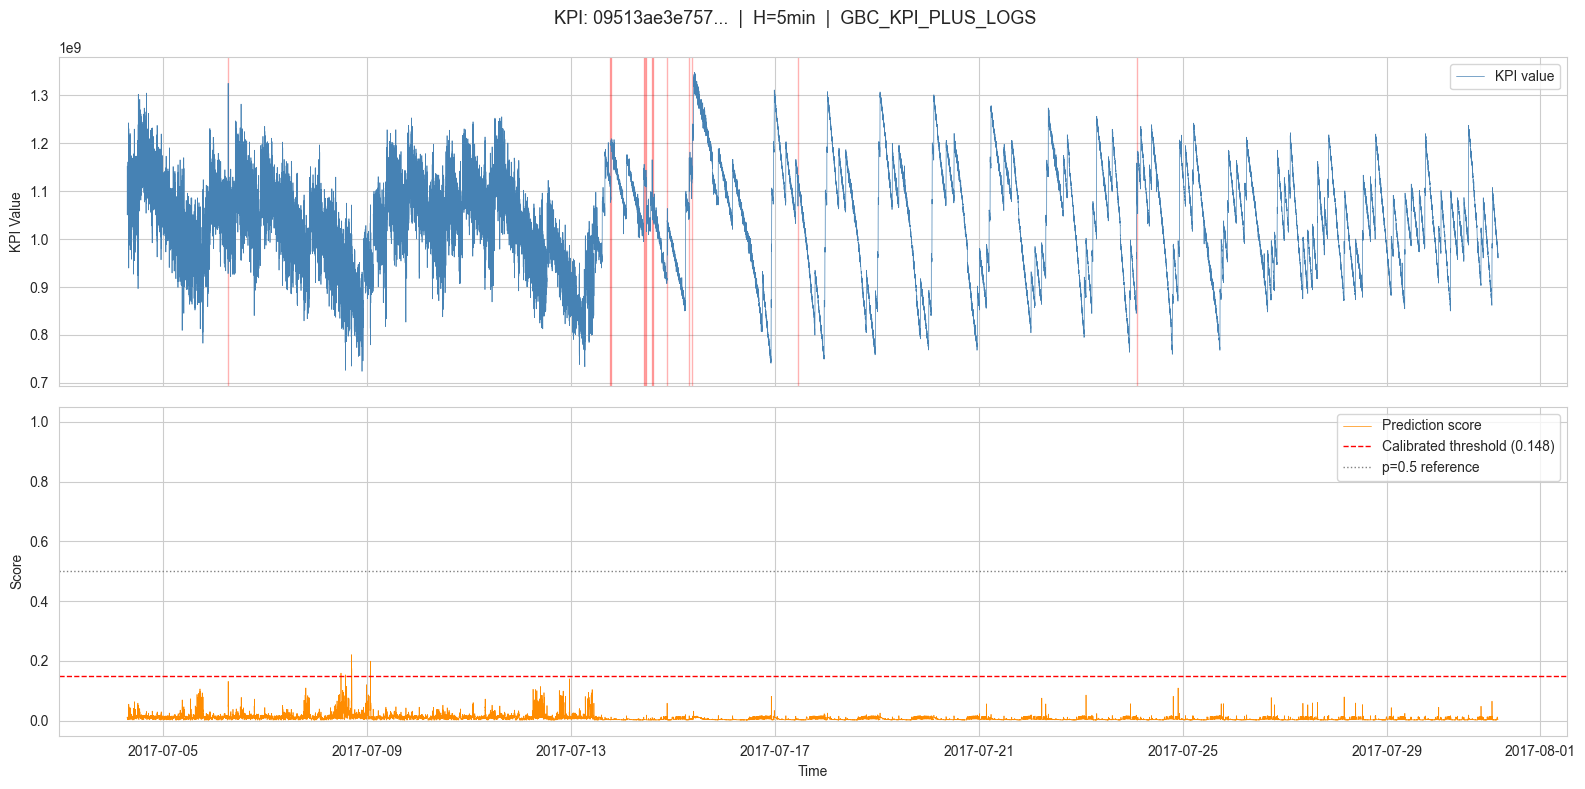

Saved: figures/timelines/kpi_09513ae3e75778a3_H10_GBC_KPI_PLUS_LOGS.png


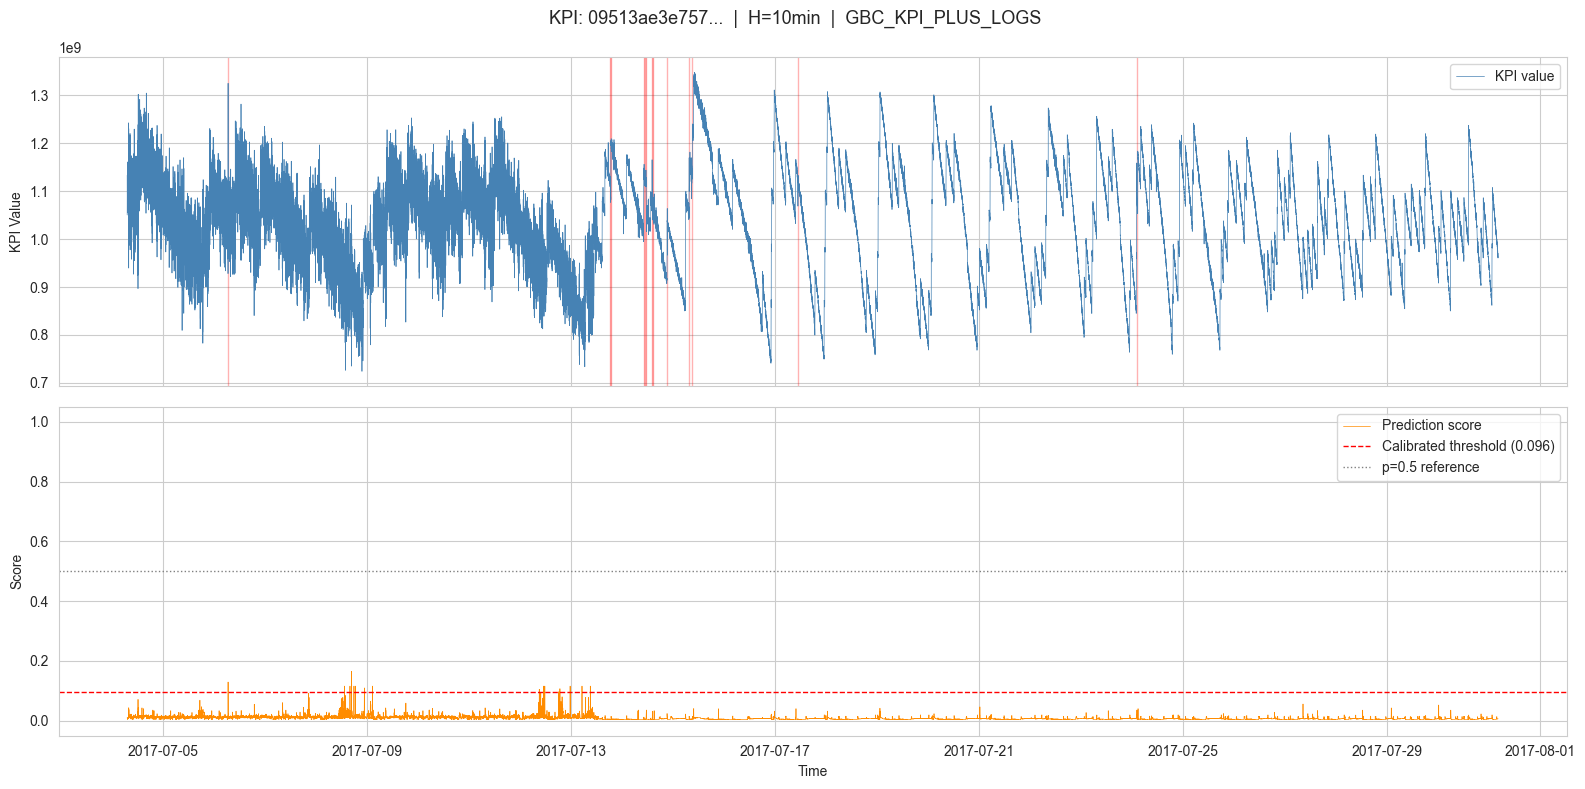

Saved: figures/timelines/kpi_09513ae3e75778a3_H15_GBC_KPI_PLUS_LOGS.png


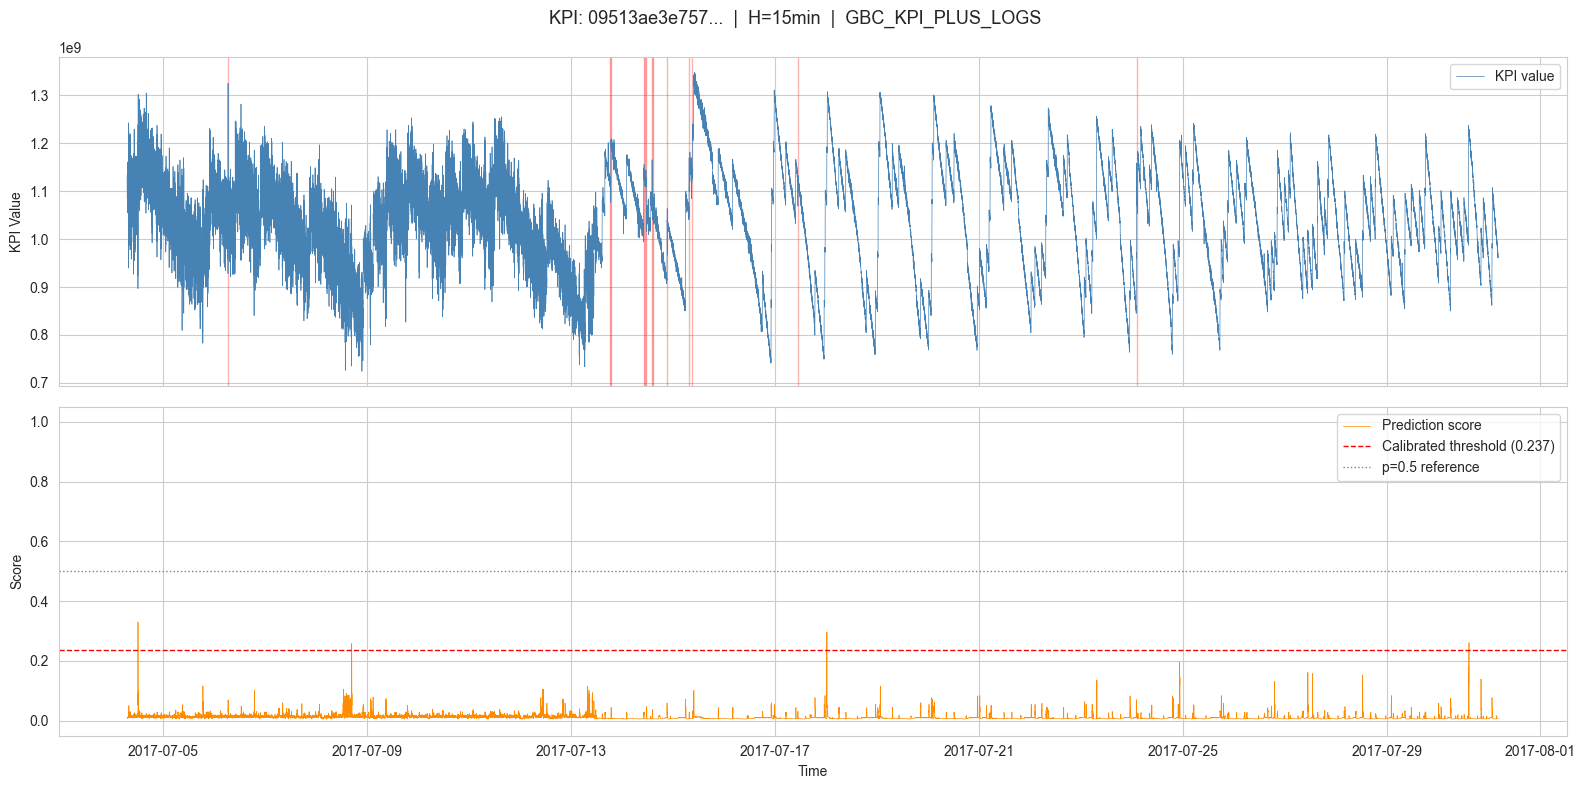

Saved: figures/timelines/kpi_1c35dbf57f55f5e4_H5_GBC_KPI_PLUS_LOGS.png


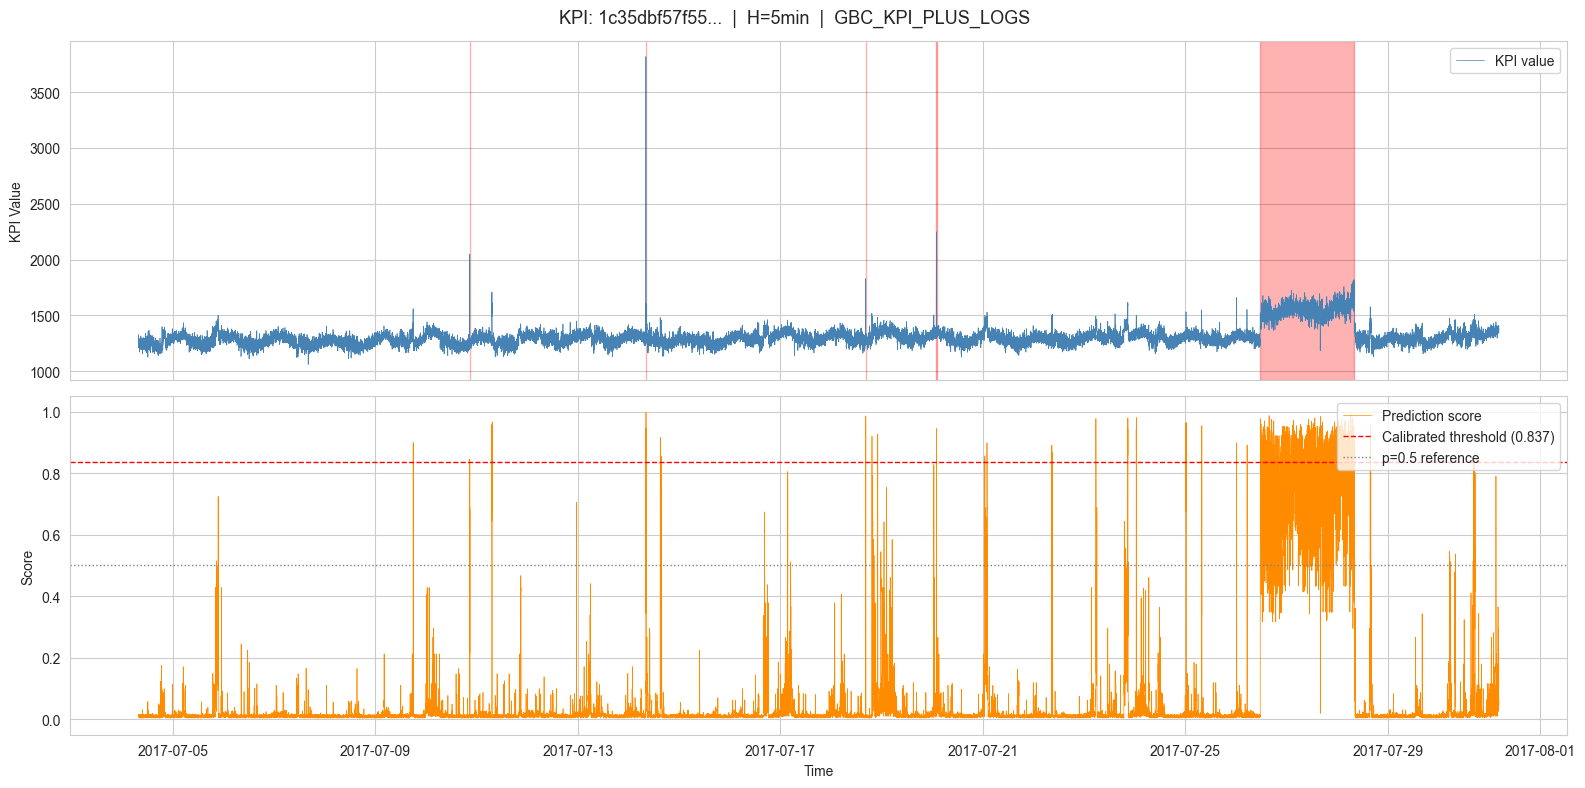

Saved: figures/timelines/kpi_1c35dbf57f55f5e4_H10_GBC_KPI_PLUS_LOGS.png


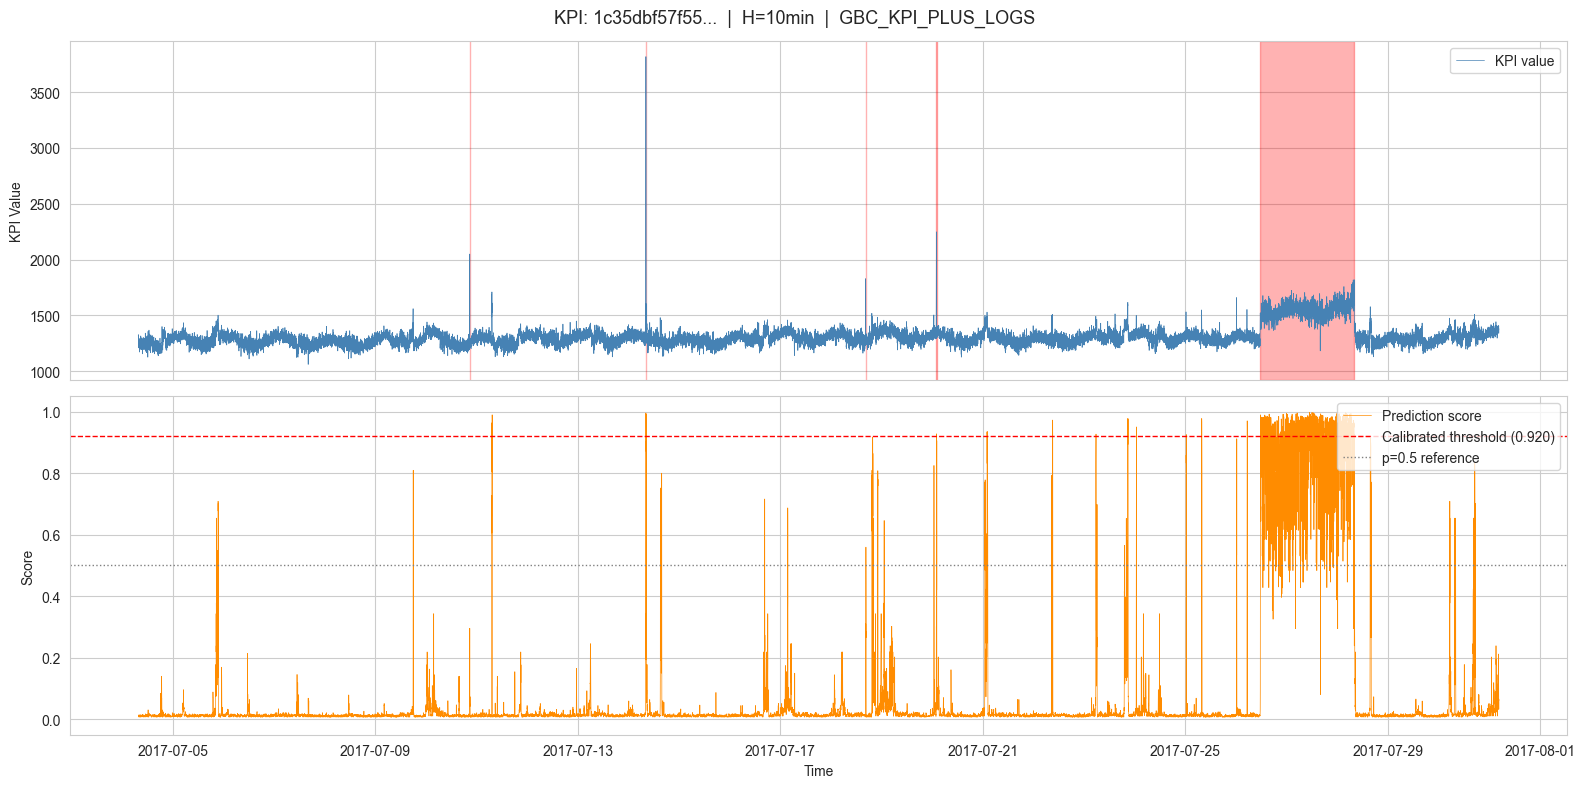

Saved: figures/timelines/kpi_1c35dbf57f55f5e4_H15_GBC_KPI_PLUS_LOGS.png


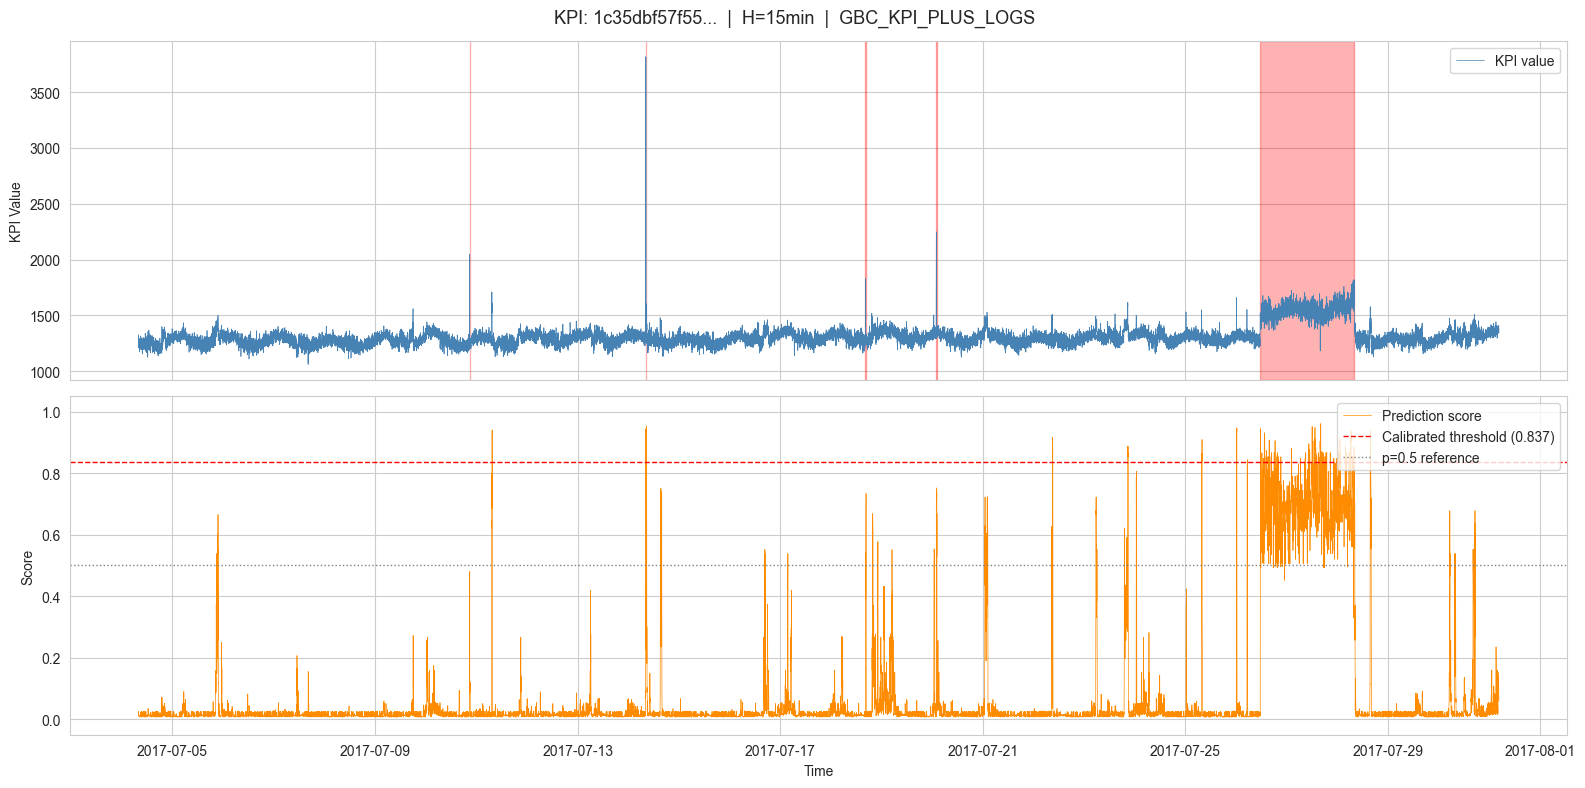

In [ ]:
# Cell 18 — Timeline plots for representative KPIs

# Select KPIs with varying anomaly rates that have test anomalies
kpi_anomaly_rates = []
for kpi_id in kpi_meta_df['KPI ID']:
    fd = feature_data[(HORIZONS[0], 'KPI_PLUS_LOGS')]
    meta_test = fd['meta_test']
    kpi_mask = (meta_test['KPI_ID'].values == kpi_id)
    if kpi_mask.sum() > 0:
        test_anomaly_rate = meta_test.loc[kpi_mask, 'label_orig'].mean()
        if test_anomaly_rate > 0:
            kpi_anomaly_rates.append((kpi_id, test_anomaly_rate))

kpi_anomaly_rates.sort(key=lambda x: x[1])

# Pick low, medium, high anomaly rate KPIs
n = len(kpi_anomaly_rates)
selected_kpis = [
    kpi_anomaly_rates[0][0],          # lowest
    kpi_anomaly_rates[n//2][0],       # middle
    kpi_anomaly_rates[-1][0],         # highest
]

print(f'Selected {len(selected_kpis)} representative KPIs for timeline plots.')
for kpi_id in selected_kpis:
    rate = dict(kpi_anomaly_rates)[kpi_id]
    print(f'  {kpi_id[:12]}... test anomaly rate={rate:.4f}')
    
for kpi_id in selected_kpis:
    for H in HORIZONS:
        plot_kpi_timeline(kpi_id, H, save=True, out_dir='figures/timelines')

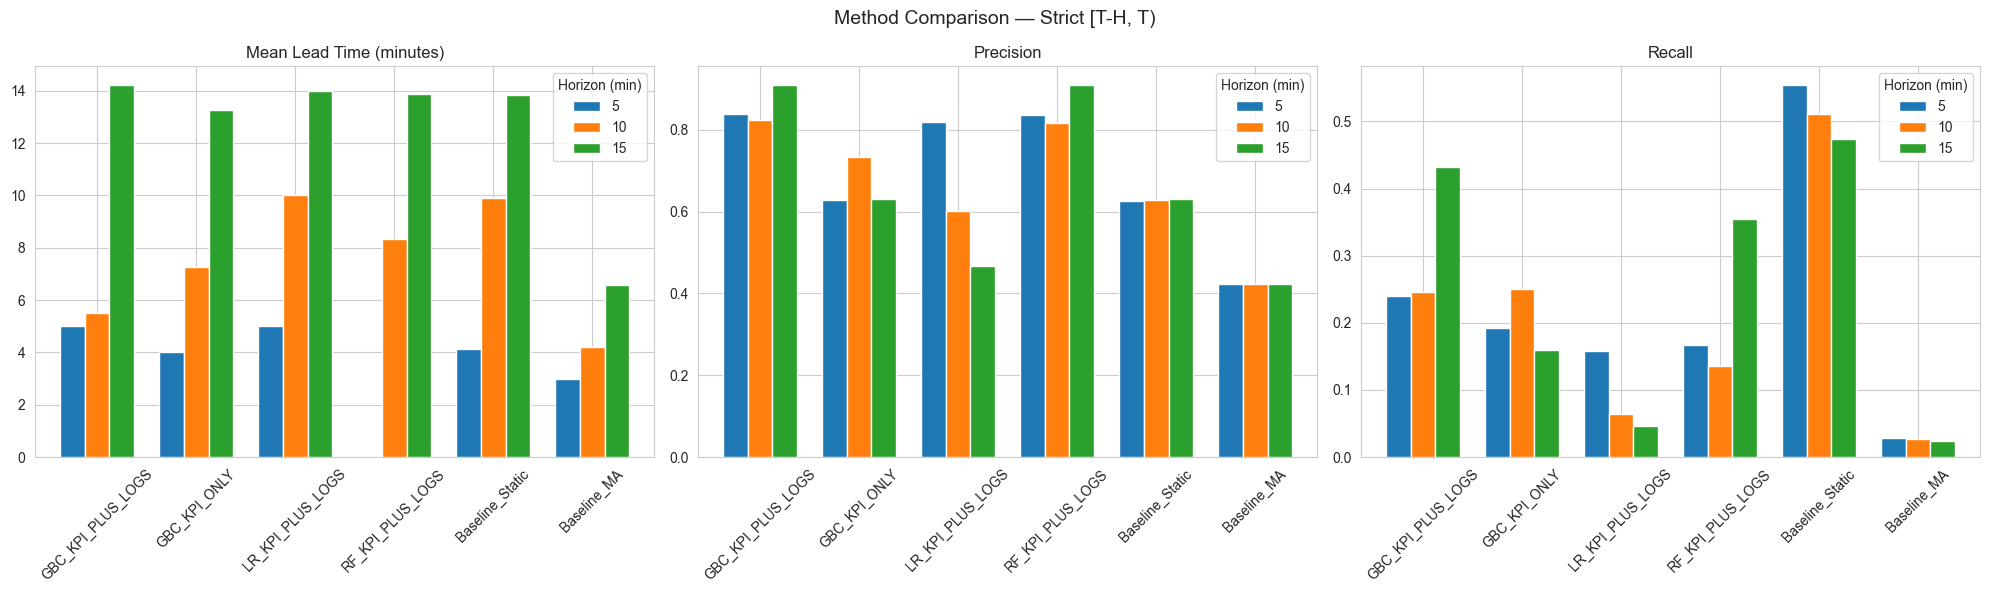

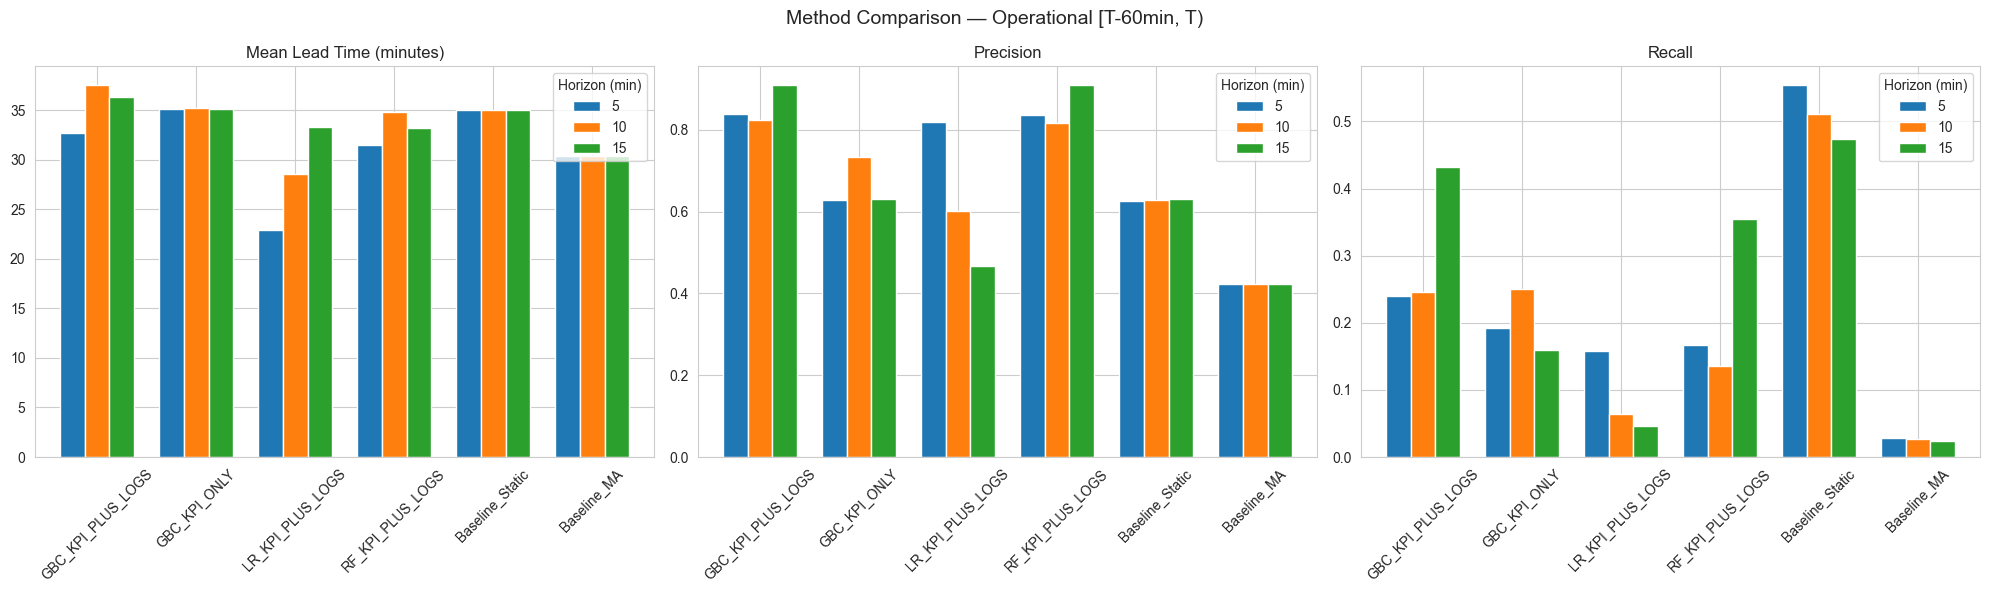

In [ ]:
# Cell 19 — Comparison bar charts

# Filter to primary methods for readability
primary_methods = ['GBC_KPI_PLUS_LOGS', 'GBC_KPI_ONLY', 'LR_KPI_PLUS_LOGS', 
                   'RF_KPI_PLUS_LOGS', 'Baseline_Static', 'Baseline_MA']


for window_name, window_label in [('strict', 'Strict [T-H, T)'), ('operational', 'Operational [T-60min, T)')]:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Method Comparison — {window_label}', fontsize=14)

    rdf = results_df[
        (results_df['Method'].isin(primary_methods)) & 
        (results_df['Eval Window'] == window_name)
    ].copy()

    for ax, metric, title in zip(axes, 
        ['Mean Lead Time', 'Precision', 'Recall'],
        ['Mean Lead Time (minutes)', 'Precision', 'Recall']):
        
        pivot = rdf.pivot_table(index='Method', columns='Horizon', values=metric, aggfunc='first')
        pivot = pivot.reindex(primary_methods)
        pivot.plot(kind='bar', ax=ax, width=0.75)
        ax.set_title(title)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title='Horizon (min)')

    plt.tight_layout()
    
    os.makedirs('figures', exist_ok=True)
    plt.savefig(
        f'figures/comparison_bar_charts_{window_name}.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

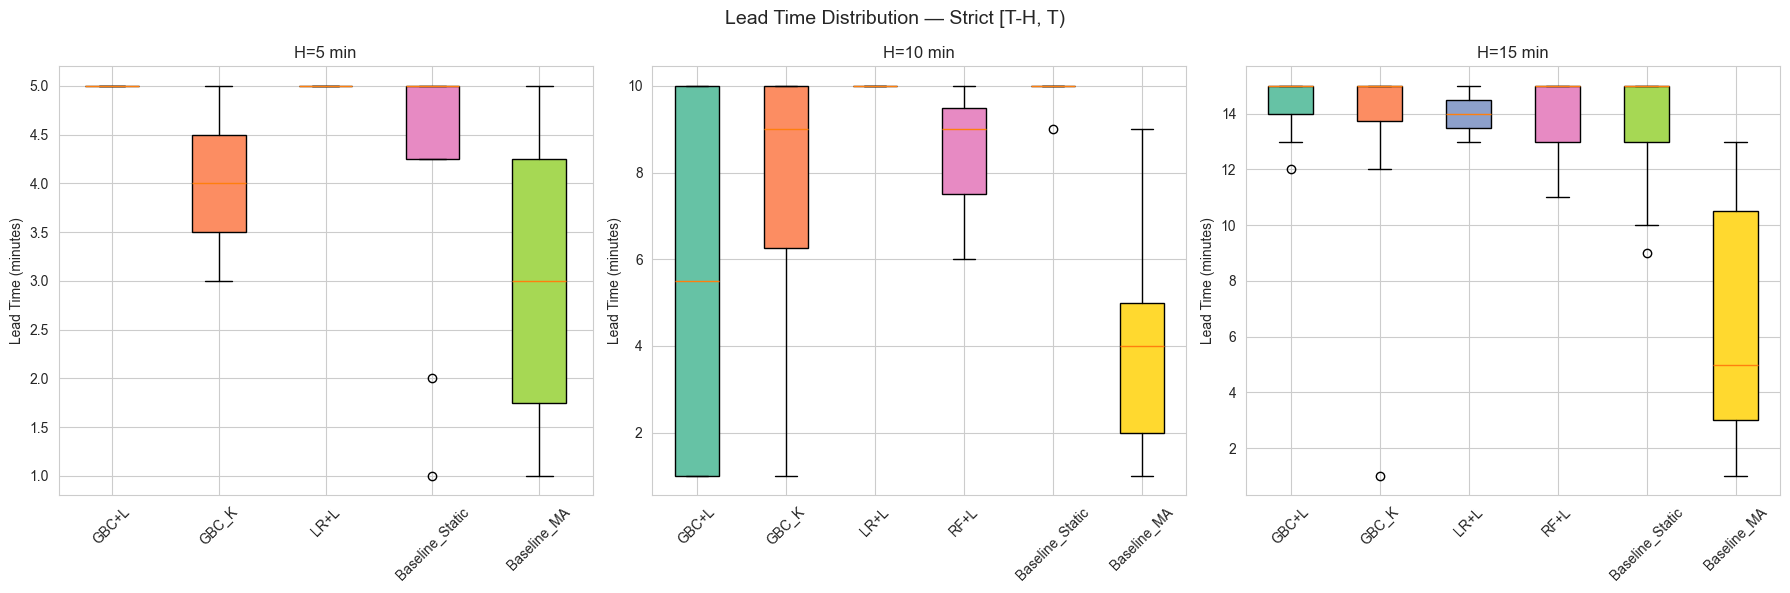

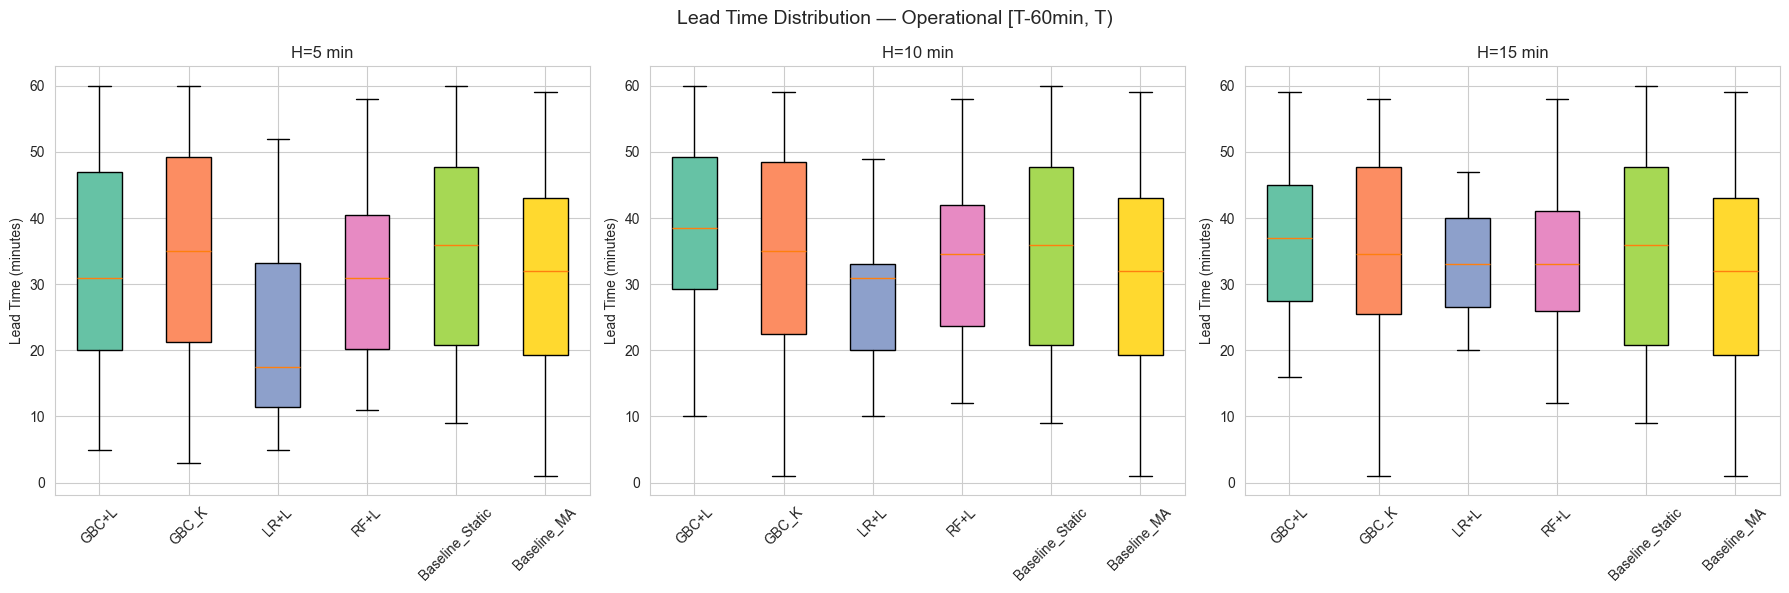

In [ ]:
# Cell 20 — Lead time distribution box plots

for window_name, window_label in [('strict', 'Strict [T-H, T)'), ('operational', 'Operational [T-60min, T)')]:
    fig, axes = plt.subplots(1, len(HORIZONS), figsize=(18, 6))
    fig.suptitle(f'Lead Time Distribution — {window_label}', fontsize=14)

    for ax, H in zip(axes, HORIZONS):
        box_data = []
        box_labels = []
        
        for method in primary_methods:
            lt_key = (method, H, window_name)
            if lt_key in lead_time_details and len(lead_time_details[lt_key]) > 0:
                box_data.append(lead_time_details[lt_key])
                box_labels.append(method.replace('_KPI_PLUS_LOGS', '+L').replace('_KPI_ONLY', '_K'))
        
        if box_data:
            bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)
            colors = sns.color_palette('Set2', len(box_data))
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
        
        ax.set_title(f'H={H} min')
        ax.set_ylabel('Lead Time (minutes)')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    
    os.makedirs('figures', exist_ok=True)
    plt.savefig(
        f'figures/lead_time_boxplots_{window_name}.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

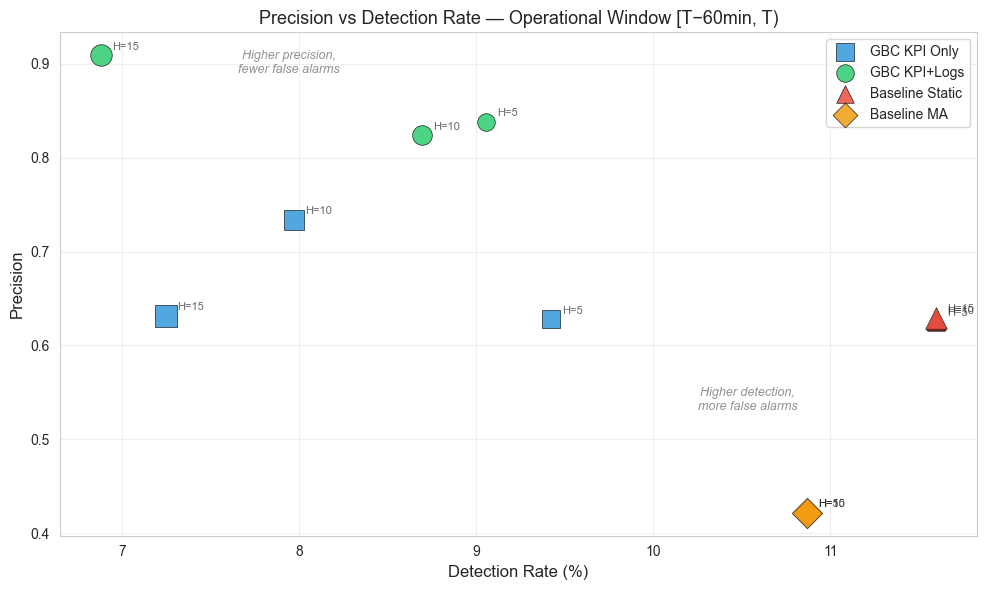

Saved: figures/precision_vs_detection_operational.png


In [ ]:
# Cell 21 — Precision vs Detection Rate scatter (Operational Window)

fig, ax = plt.subplots(figsize=(10, 6))

# Extract data from results_df for operational window, GBC + baselines only
op_results = results_df[
    (results_df['Eval Window'] == 'operational') &
    (results_df['Method'].isin(['GBC_KPI_PLUS_LOGS', 'GBC_KPI_ONLY', 'Baseline_Static', 'Baseline_MA']))
].copy()

color_map = {
    'GBC_KPI_PLUS_LOGS': '#2ecc71',
    'GBC_KPI_ONLY': '#3498db',
    'Baseline_Static': '#e74c3c',
    'Baseline_MA': '#f39c12',
}
marker_map = {
    'GBC_KPI_PLUS_LOGS': 'o',
    'GBC_KPI_ONLY': 's',
    'Baseline_Static': '^',
    'Baseline_MA': 'D',
}
label_map = {
    'GBC_KPI_PLUS_LOGS': 'GBC KPI+Logs',
    'GBC_KPI_ONLY': 'GBC KPI Only',
    'Baseline_Static': 'Baseline Static',
    'Baseline_MA': 'Baseline MA',
}

plotted_labels = set()
for _, row in op_results.iterrows():
    method = row['Method']
    H = row['Horizon']
    prec = row['Precision']
    det_rate = row['Detection Rate'] * 100  # convert to percentage

    label = label_map[method] if method not in plotted_labels else None
    ax.scatter(det_rate, prec,
               c=color_map[method], marker=marker_map[method],
               s=120 + H * 8, edgecolors='black', linewidth=0.5,
               label=label, alpha=0.85, zorder=5)
    ax.annotate(f'H={H}', (det_rate, prec),
                textcoords="offset points", xytext=(8, 4), fontsize=8, alpha=0.7)
    plotted_labels.add(method)

ax.set_xlabel('Detection Rate (%)', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision vs Detection Rate — Operational Window [T−60min, T)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Annotations for tradeoff regions
ax.annotate('Higher precision,\nfewer false alarms',
            xy=(0.25, 0.92), xycoords='axes fraction',
            fontsize=9, fontstyle='italic', alpha=0.5, ha='center')
ax.annotate('Higher detection,\nmore false alarms',
            xy=(0.75, 0.25), xycoords='axes fraction',
            fontsize=9, fontstyle='italic', alpha=0.5, ha='center')

plt.tight_layout()

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/precision_vs_detection_operational.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: figures/precision_vs_detection_operational.png')

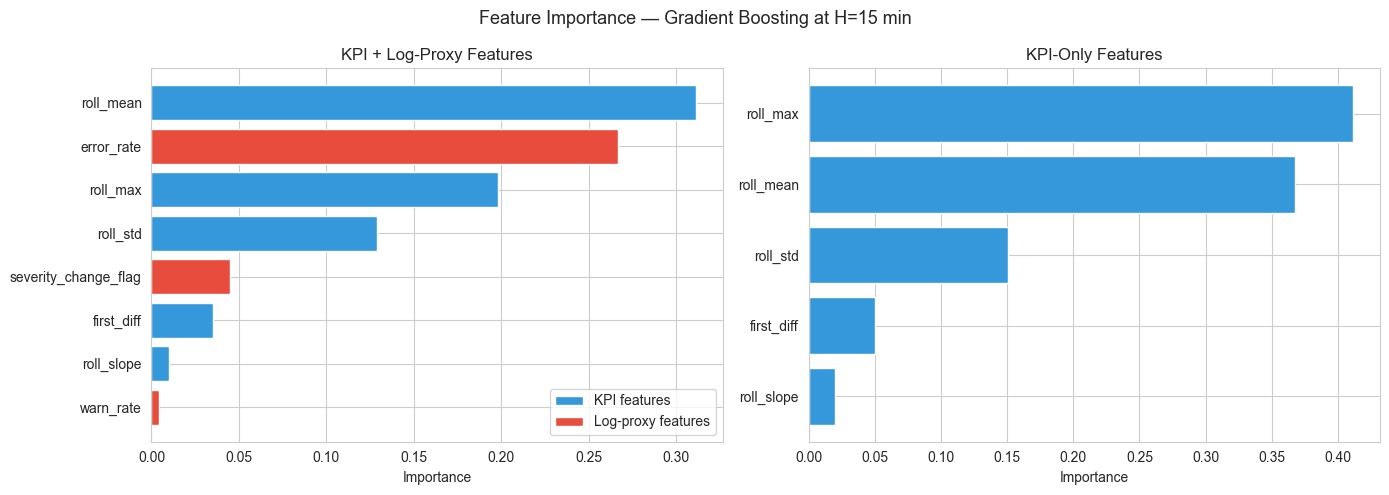

Saved: figures/feature_importance_H15.png

KPI+Logs feature importances:
  roll_mean                : 0.3112
  roll_max                 : 0.1982
  roll_std                 : 0.1292
  roll_slope               : 0.0103
  first_diff               : 0.0351
  error_rate               : 0.2668 (log-proxy)
  warn_rate                : 0.0042 (log-proxy)
  severity_change_flag     : 0.0450 (log-proxy)

KPI-Only feature importances:
  roll_mean                : 0.3677
  roll_max                 : 0.4113
  roll_std                 : 0.1509
  roll_slope               : 0.0199
  first_diff               : 0.0502


In [ ]:
# Cell 22 — Feature Importance Comparison (GBC at H=15)

from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance — Gradient Boosting at H=15 min', fontsize=13)

# --- KPI + Logs ---
model_kl = trained_models[(15, 'KPI_PLUS_LOGS', 'GBC')]
importances_kl = model_kl.feature_importances_
names_kl = np.array(KPI_PLUS_LOGS_COLS)  # ['roll_mean', 'roll_max', 'roll_std', 'roll_slope', 'first_diff', 'error_rate', 'warn_rate', 'severity_change_flag']

sorted_idx_kl = np.argsort(importances_kl)
colors_kl = ['#e74c3c' if n in LOG_PROXY_COLS else '#3498db' for n in names_kl[sorted_idx_kl]]

ax1.barh(names_kl[sorted_idx_kl], importances_kl[sorted_idx_kl], color=colors_kl)
ax1.set_xlabel('Importance')
ax1.set_title('KPI + Log-Proxy Features')
legend_elements = [Patch(facecolor='#3498db', label='KPI features'),
                   Patch(facecolor='#e74c3c', label='Log-proxy features')]
ax1.legend(handles=legend_elements, loc='lower right')

# --- KPI Only ---
model_k = trained_models[(15, 'KPI_ONLY', 'GBC')]
importances_k = model_k.feature_importances_
names_k = np.array(KPI_ONLY_COLS)  # ['roll_mean', 'roll_max', 'roll_std', 'roll_slope', 'first_diff']

sorted_idx_k = np.argsort(importances_k)

ax2.barh(names_k[sorted_idx_k], importances_k[sorted_idx_k], color='#3498db')
ax2.set_xlabel('Importance')
ax2.set_title('KPI-Only Features')

plt.tight_layout()

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/feature_importance_H15.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: figures/feature_importance_H15.png')

# Print exact values for reference
print('\nKPI+Logs feature importances:')
for name, imp in zip(names_kl, importances_kl):
    tag = ' (log-proxy)' if name in LOG_PROXY_COLS else ''
    print(f'  {name:25s}: {imp:.4f}{tag}')

print('\nKPI-Only feature importances:')
for name, imp in zip(names_k, importances_k):
    print(f'  {name:25s}: {imp:.4f}')

In [ ]:
import joblib, json, os

os.makedirs('deployment_artifacts', exist_ok=True)

# Export the best model: GBC with KPI+Logs features at H=15
best_model = trained_models[(15, 'KPI_PLUS_LOGS', 'GBC')]
joblib.dump(best_model, 'deployment_artifacts/model_h15.pkl')

# Also export models for other horizons
for H in [5, 10]:
    m = trained_models[(H, 'KPI_PLUS_LOGS', 'GBC')]
    joblib.dump(m, f'deployment_artifacts/model_h{H}.pkl')

# Export calibrated thresholds
thresholds_export = {}
for H in [5, 10, 15]:
    key = (H, 'KPI_PLUS_LOGS', 'GBC')
    thresholds_export[str(H)] = {
        kpi_id: float(thresh)
        for kpi_id, thresh in calibrated_thresholds[key].items()
    }
with open('deployment_artifacts/thresholds.json', 'w') as f:
    json.dump(thresholds_export, f, indent=2)

# Export feature importance for analytics endpoint
model_kl = trained_models[(15, 'KPI_PLUS_LOGS', 'GBC')]
feature_names = ['roll_mean','roll_max','roll_std','roll_slope',
                 'first_diff','error_rate','warn_rate',
                 'severity_change_flag']
importances = model_kl.feature_importances_
feature_importance_data = [
    {'feature': name, 'importance': round(float(imp), 4),
     'type': 'log' if name in ['error_rate','warn_rate',
            'severity_change_flag'] else 'kpi'}
    for name, imp in sorted(zip(feature_names, importances),
                            key=lambda x: -x[1])
]
with open('deployment_artifacts/feature_importances.json', 'w') as f:
    json.dump(feature_importance_data, f, indent=2)

print('Exported artifacts:')
for f_name in os.listdir('deployment_artifacts'):
    size = os.path.getsize(f'deployment_artifacts/{f_name}')
    print(f'  {f_name}: {size/1024:.1f} KB')


Exported artifacts:
  model_h15.pkl: 139.9 KB
  model_h10.pkl: 139.6 KB
  model_h5.pkl: 139.9 KB
  thresholds.json: 3.4 KB
  feature_importances.json: 0.6 KB
